In [2]:
library(Seurat)
library(harmony)
library(spacexr)

library(ggplot2)
library(ggplotify)
library(ggsci)
library(scatterpie)
library(patchwork)
library(ggrastr)

library(ComplexHeatmap)
library(grid)
library(circlize)

library(Matrix)
library(dplyr)

Attaching SeuratObject

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode

Loading required package: Rcpp

scatterpie v0.2.6 Learn more at https://yulab-smu.top/



Loading required package: grid

ComplexHeatmap version 2.27.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


ci

In [3]:
source('../R_function/ST_plot.R')
source('../R_function/knn_function.R')

In [4]:
obj_fish_ST_raw <- readRDS('/mnt/gandan/lishenglong/mut_sp/data/orig_data/fish_all.rds')

In [5]:
obj_fish_ST_raw$x_raw <- obj_fish_ST_raw$x
obj_fish_ST_raw$y_raw <- obj_fish_ST_raw$y

In [6]:
rotation_coor <- function(raw_df,rotation){
    r_pi <- rotation*pi/180
    r_matrix <- matrix(c(cos(r_pi),-sin(r_pi),
                         sin(r_pi),cos(r_pi)),ncol=2,nrow=2)
    r_df <- as.matrix(raw_df)%*%r_matrix
    return(r_df)
    }

In [7]:
obj_fish_ST_raw@meta.data[,c('x','y')] <- obj_fish_ST_raw@meta.data[,c('x_raw','y_raw')]

#obj_fish_ST_raw@meta.data[obj_fish_ST_raw@meta.data$slice_code=='D03558D2.left','y'] <- -obj_fish_ST_raw@meta.data[obj_fish_ST_raw@meta.data$slice_code=='D03558D2.left','y_raw']
#obj_fish_ST_raw@meta.data[obj_fish_ST_raw@meta.data$slice_code=='D03558D2.right',c('x','y')] <- -obj_fish_ST_raw@meta.data[obj_fish_ST_raw@meta.data$slice_code=='D03558D2.right',c('x_raw','y_raw')]
#obj_fish_ST_raw@meta.data[obj_fish_ST_raw@meta.data$slice_code=='D03558D4.left','y'] <- -obj_fish_ST_raw@meta.data[obj_fish_ST_raw@meta.data$slice_code=='D03558D4.left','y_raw']
#obj_fish_ST_raw@meta.data[obj_fish_ST_raw@meta.data$slice_code=='D03558D4.right',c('x','y')] <- -obj_fish_ST_raw@meta.data[obj_fish_ST_raw@meta.data$slice_code=='D03558D4.right',c('x_raw','y_raw')]
#
#
obj_fish_ST_raw@meta.data[obj_fish_ST_raw@meta.data$slice_code=='D03558D2.left',c('x','y')] <- rotation_coor(obj_fish_ST_raw@meta.data[obj_fish_ST_raw@meta.data$slice_code=='D03558D2.left',c('x','y')],-90)
obj_fish_ST_raw@meta.data[obj_fish_ST_raw@meta.data$slice_code=='D03558D2.right',c('x','y')] <- rotation_coor(obj_fish_ST_raw@meta.data[obj_fish_ST_raw@meta.data$slice_code=='D03558D2.right',c('x','y')],-90)
obj_fish_ST_raw@meta.data[obj_fish_ST_raw@meta.data$slice_code=='D03558D4.left',c('x','y')] <- rotation_coor(obj_fish_ST_raw@meta.data[obj_fish_ST_raw@meta.data$slice_code=='D03558D4.left',c('x','y')],-90)
obj_fish_ST_raw@meta.data[obj_fish_ST_raw@meta.data$slice_code=='D03558D4.right',c('x','y')] <- rotation_coor(obj_fish_ST_raw@meta.data[obj_fish_ST_raw@meta.data$slice_code=='D03558D4.right',c('x','y')],-90)

In [314]:
head(obj_fish_ST_raw)

,orig.ident,x,y,region,n_counts,slice_code,x_raw,y_raw
,<chr>,<dbl>,<dbl>,<chr>,<int>,<chr>,<int>,<int>
39943195865150,sample,12350,-9300,granular layer,2733,D03558D2.left,9300,12350
40587440959900,sample,12700,-9450,granular layer,3383,D03558D2.left,9450,12700
43379169698050,sample,8450,-10100,central zone of dorsal telencephalon,8430,D03558D2.left,10100,8450
43593918063400,sample,9000,-10150,central zone of dorsal telencephalon,3783,D03558D2.left,10150,9000
43808666427800,sample,8600,-10200,central zone of dorsal telencephalon,6470,D03558D2.left,10200,8600
38869454040300,sample,11500,-9050,longitudinal torus,7633,D03558D2.left,9050,11500
39084202405750,sample,12150,-9100,granular layer,2986,D03558D2.left,9100,12150
40157944230150,sample,12550,-9350,granular layer,2632,D03558D2.left,9350,12550
41231686054450,sample,12850,-9600,trigeminal motor nucleus,3675,D03558D2.left,9600,12850


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


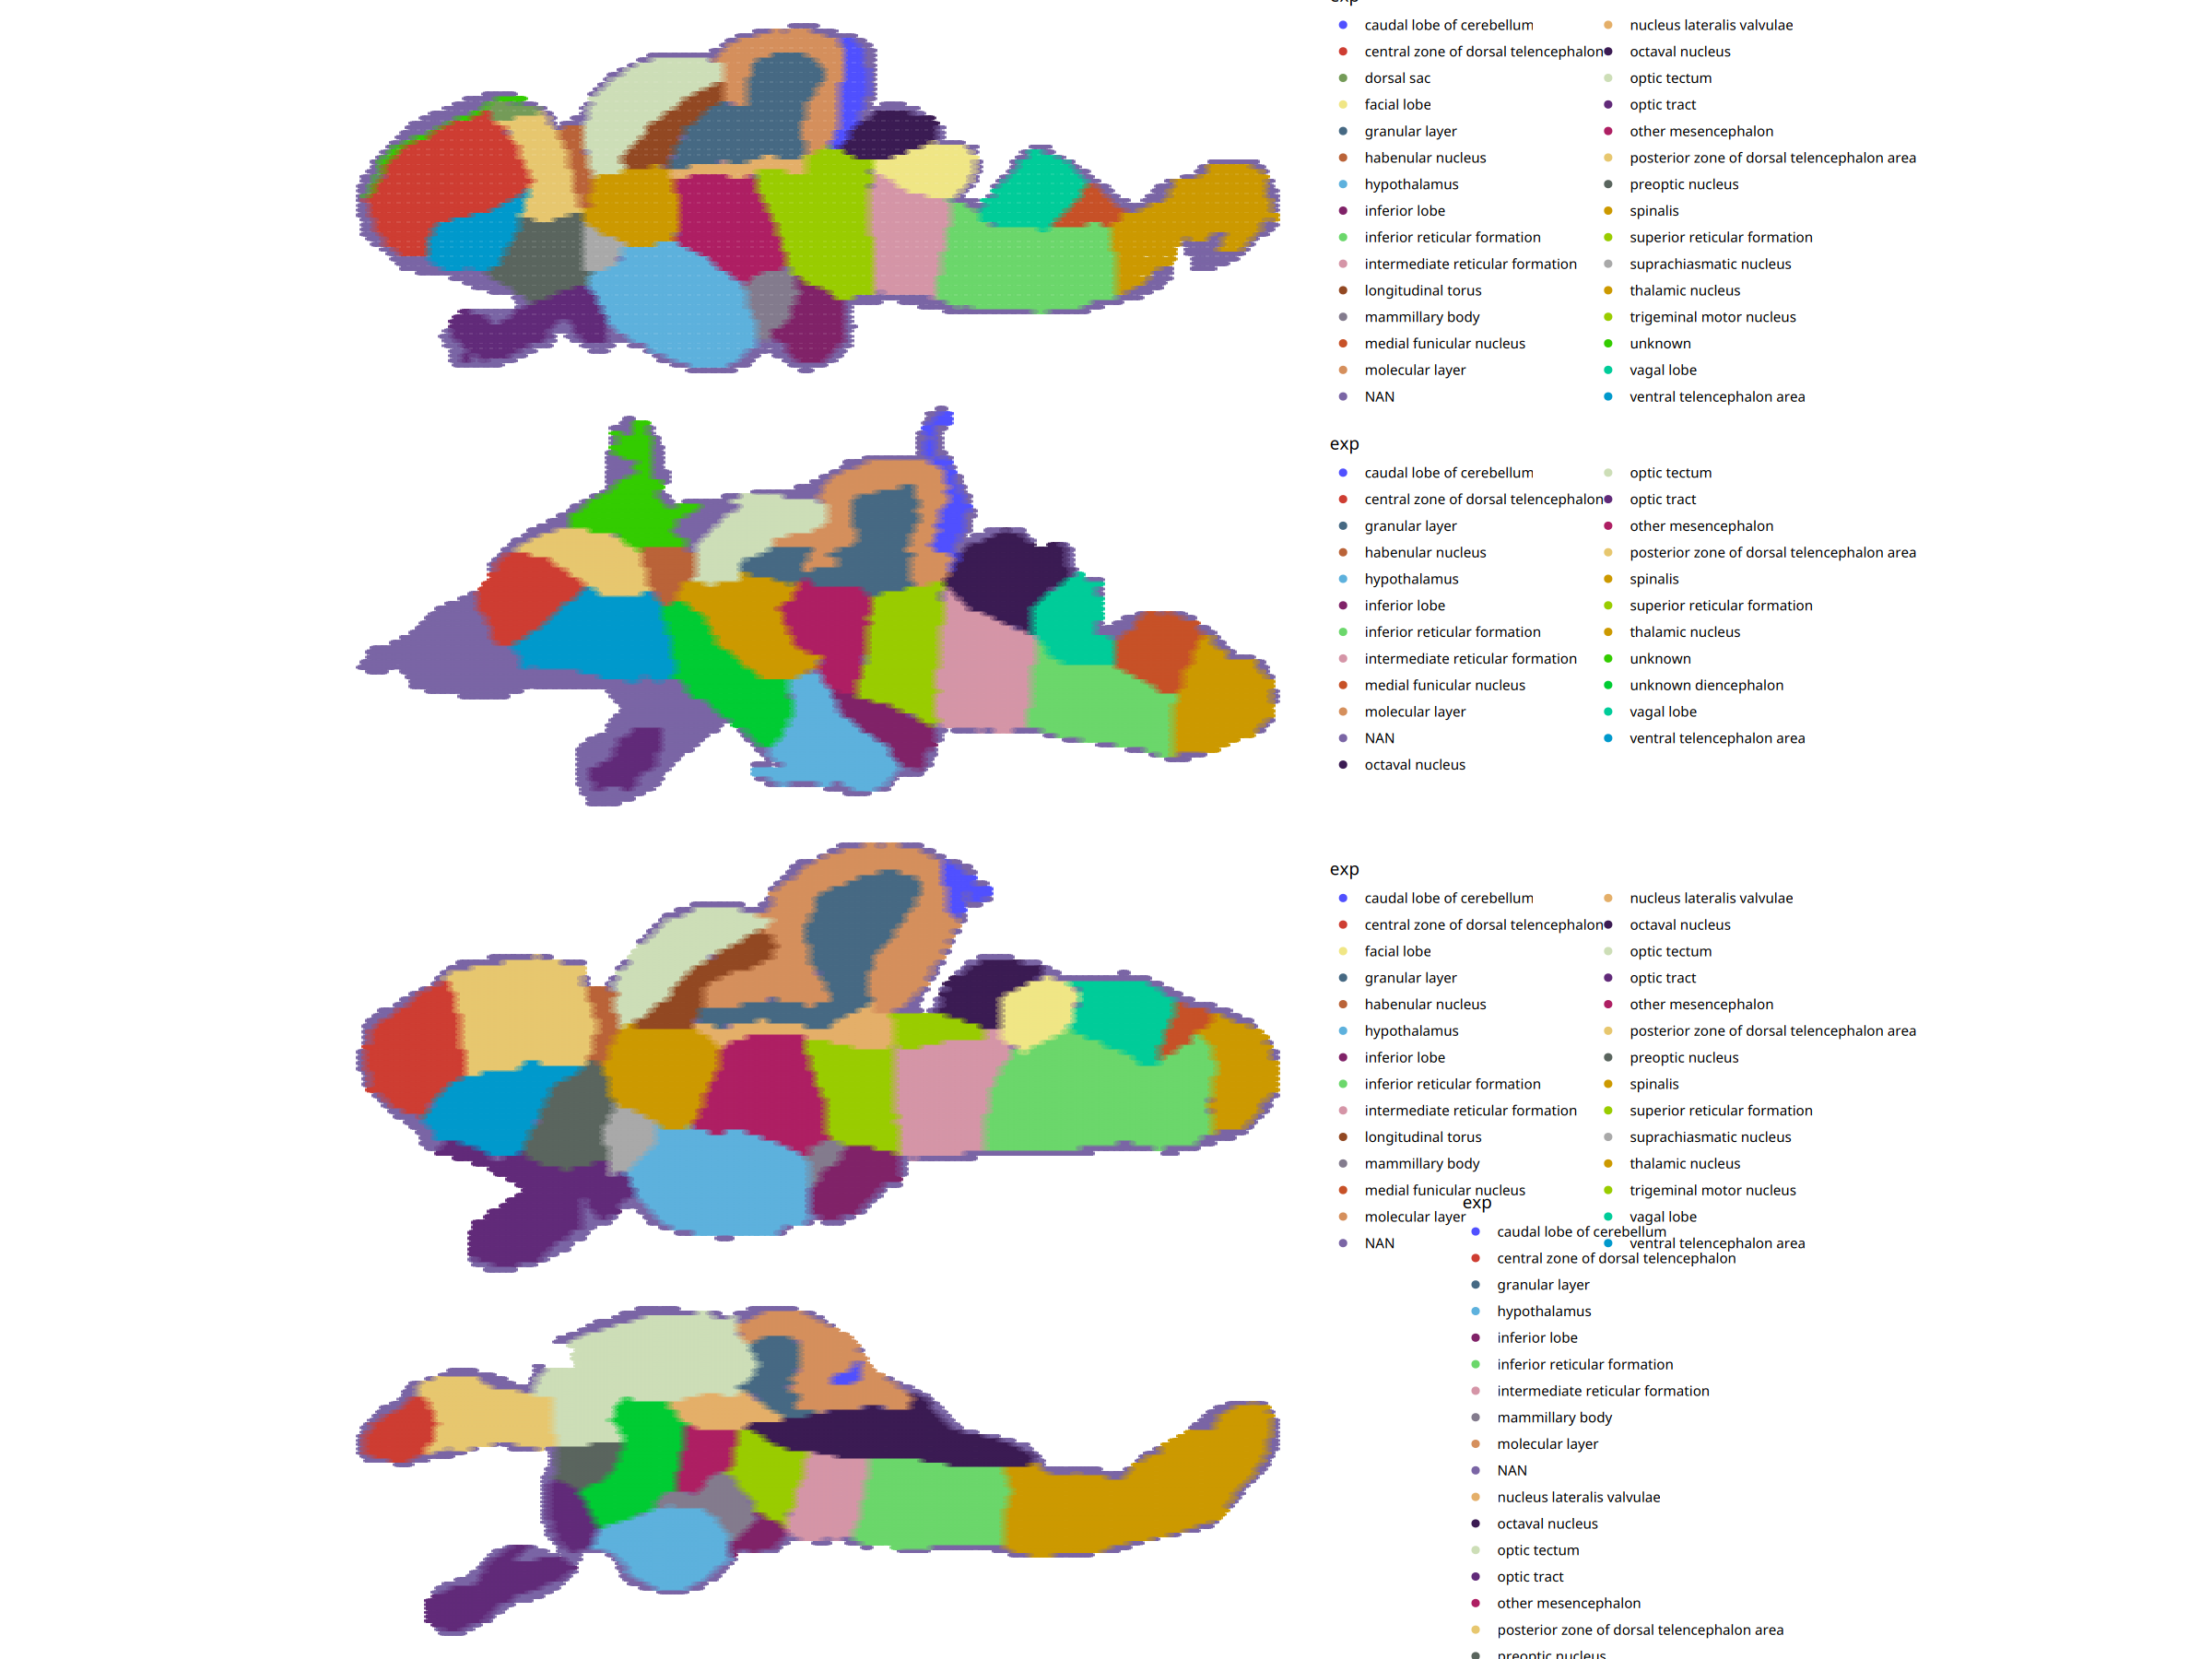

In [7]:
options(repr.plot.height=15,repr.plot.width=20)
plot_spatial_col(obj = obj_fish_ST_raw@meta.data[obj_fish_ST_raw@meta.data$slice_code=='D03558D2.left',],col_name  = 'region',size = 4)+scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_fish_ST_raw$region)))+
plot_spatial_col(obj = obj_fish_ST_raw@meta.data[obj_fish_ST_raw@meta.data$slice_code=='D03558D2.right',],col_name  = 'region',size = 4)+scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_fish_ST_raw$region)))+
plot_spatial_col(obj = obj_fish_ST_raw@meta.data[obj_fish_ST_raw@meta.data$slice_code=='D03558D4.left',],col_name  = 'region',size = 4)+scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_fish_ST_raw$region)))+
plot_spatial_col(obj = obj_fish_ST_raw@meta.data[obj_fish_ST_raw@meta.data$slice_code=='D03558D4.right',],col_name  = 'region',size = 4)+scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_fish_ST_raw$region)))+
plot_layout(nrow=4)

In [8]:
obj_fish_ST_cluster <- obj_fish_ST_raw[,obj_fish_ST_raw$region%in%c('ventral telencephalon area','central zone of dorsal telencephalon','posterior zone of dorsal telencephalon area')]
#obj_fish_ST_cluster <- obj_fish_ST_raw[,!obj_fish_ST_raw$region%in%c('NAN')]

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


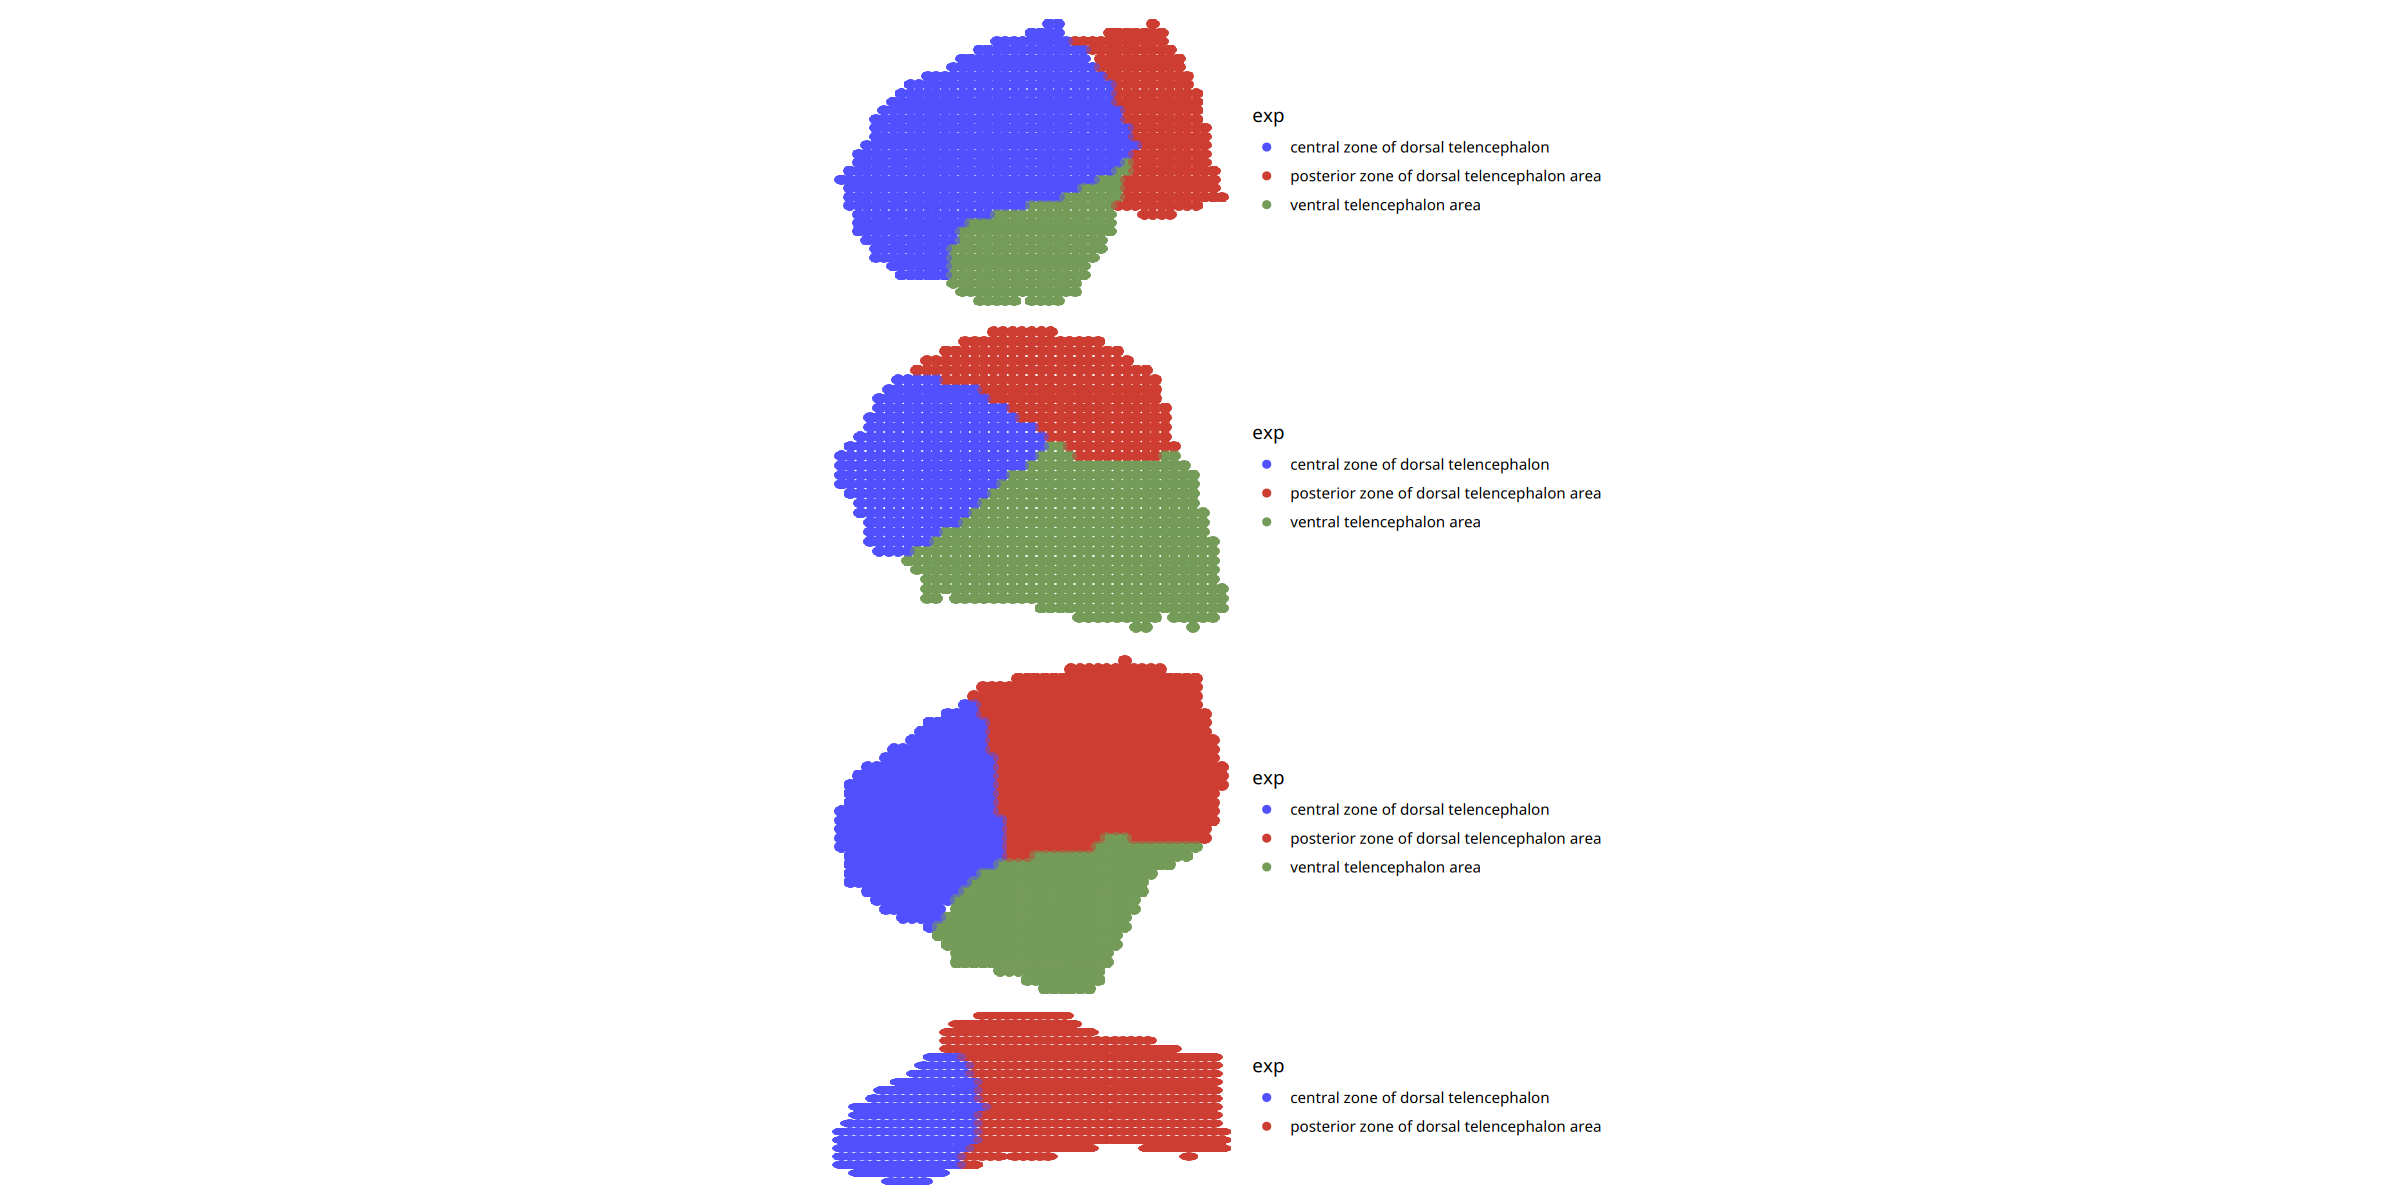

In [348]:
options(repr.plot.height=10,repr.plot.width=20)
plot_spatial_col(obj = obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D2.left',],col_name  = 'region',size = 9)+scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_fish_ST_cluster$region)))+
plot_spatial_col(obj = obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D2.right',],col_name  = 'region',size = 9)+scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_fish_ST_cluster$region)))+
plot_spatial_col(obj = obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D4.left',],col_name  = 'region',size = 9)+scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_fish_ST_cluster$region)))+
plot_spatial_col(obj = obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D4.right',],col_name  = 'region',size = 12)+scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_fish_ST_cluster$region)))+
plot_layout(nrow=4)

In [349]:
head(obj_fish_ST_cluster)

,orig.ident,x,y,region,n_counts,slice_code,x_raw,y_raw
,<chr>,<dbl>,<dbl>,<chr>,<int>,<chr>,<int>,<int>
43379169698050,sample,8450,-10100,central zone of dorsal telencephalon,8430,D03558D2.left,10100,8450
43593918063400,sample,9000,-10150,central zone of dorsal telencephalon,3783,D03558D2.left,10150,9000
43808666427800,sample,8600,-10200,central zone of dorsal telencephalon,6470,D03558D2.left,10200,8600
45097156617000,sample,9000,-10500,ventral telencephalon area,3713,D03558D2.left,10500,9000
45097156616700,sample,8700,-10500,central zone of dorsal telencephalon,6933,D03558D2.left,10500,8700
38869454038850,sample,10050,-9050,posterior zone of dorsal telencephalon area,3921,D03558D2.left,9050,10050
39084202403000,sample,9400,-9100,central zone of dorsal telencephalon,1596,D03558D2.left,9100,9400
39084202403450,sample,9850,-9100,posterior zone of dorsal telencephalon area,4365,D03558D2.left,9100,9850
39084202403700,sample,10100,-9100,posterior zone of dorsal telencephalon area,3814,D03558D2.left,9100,10100


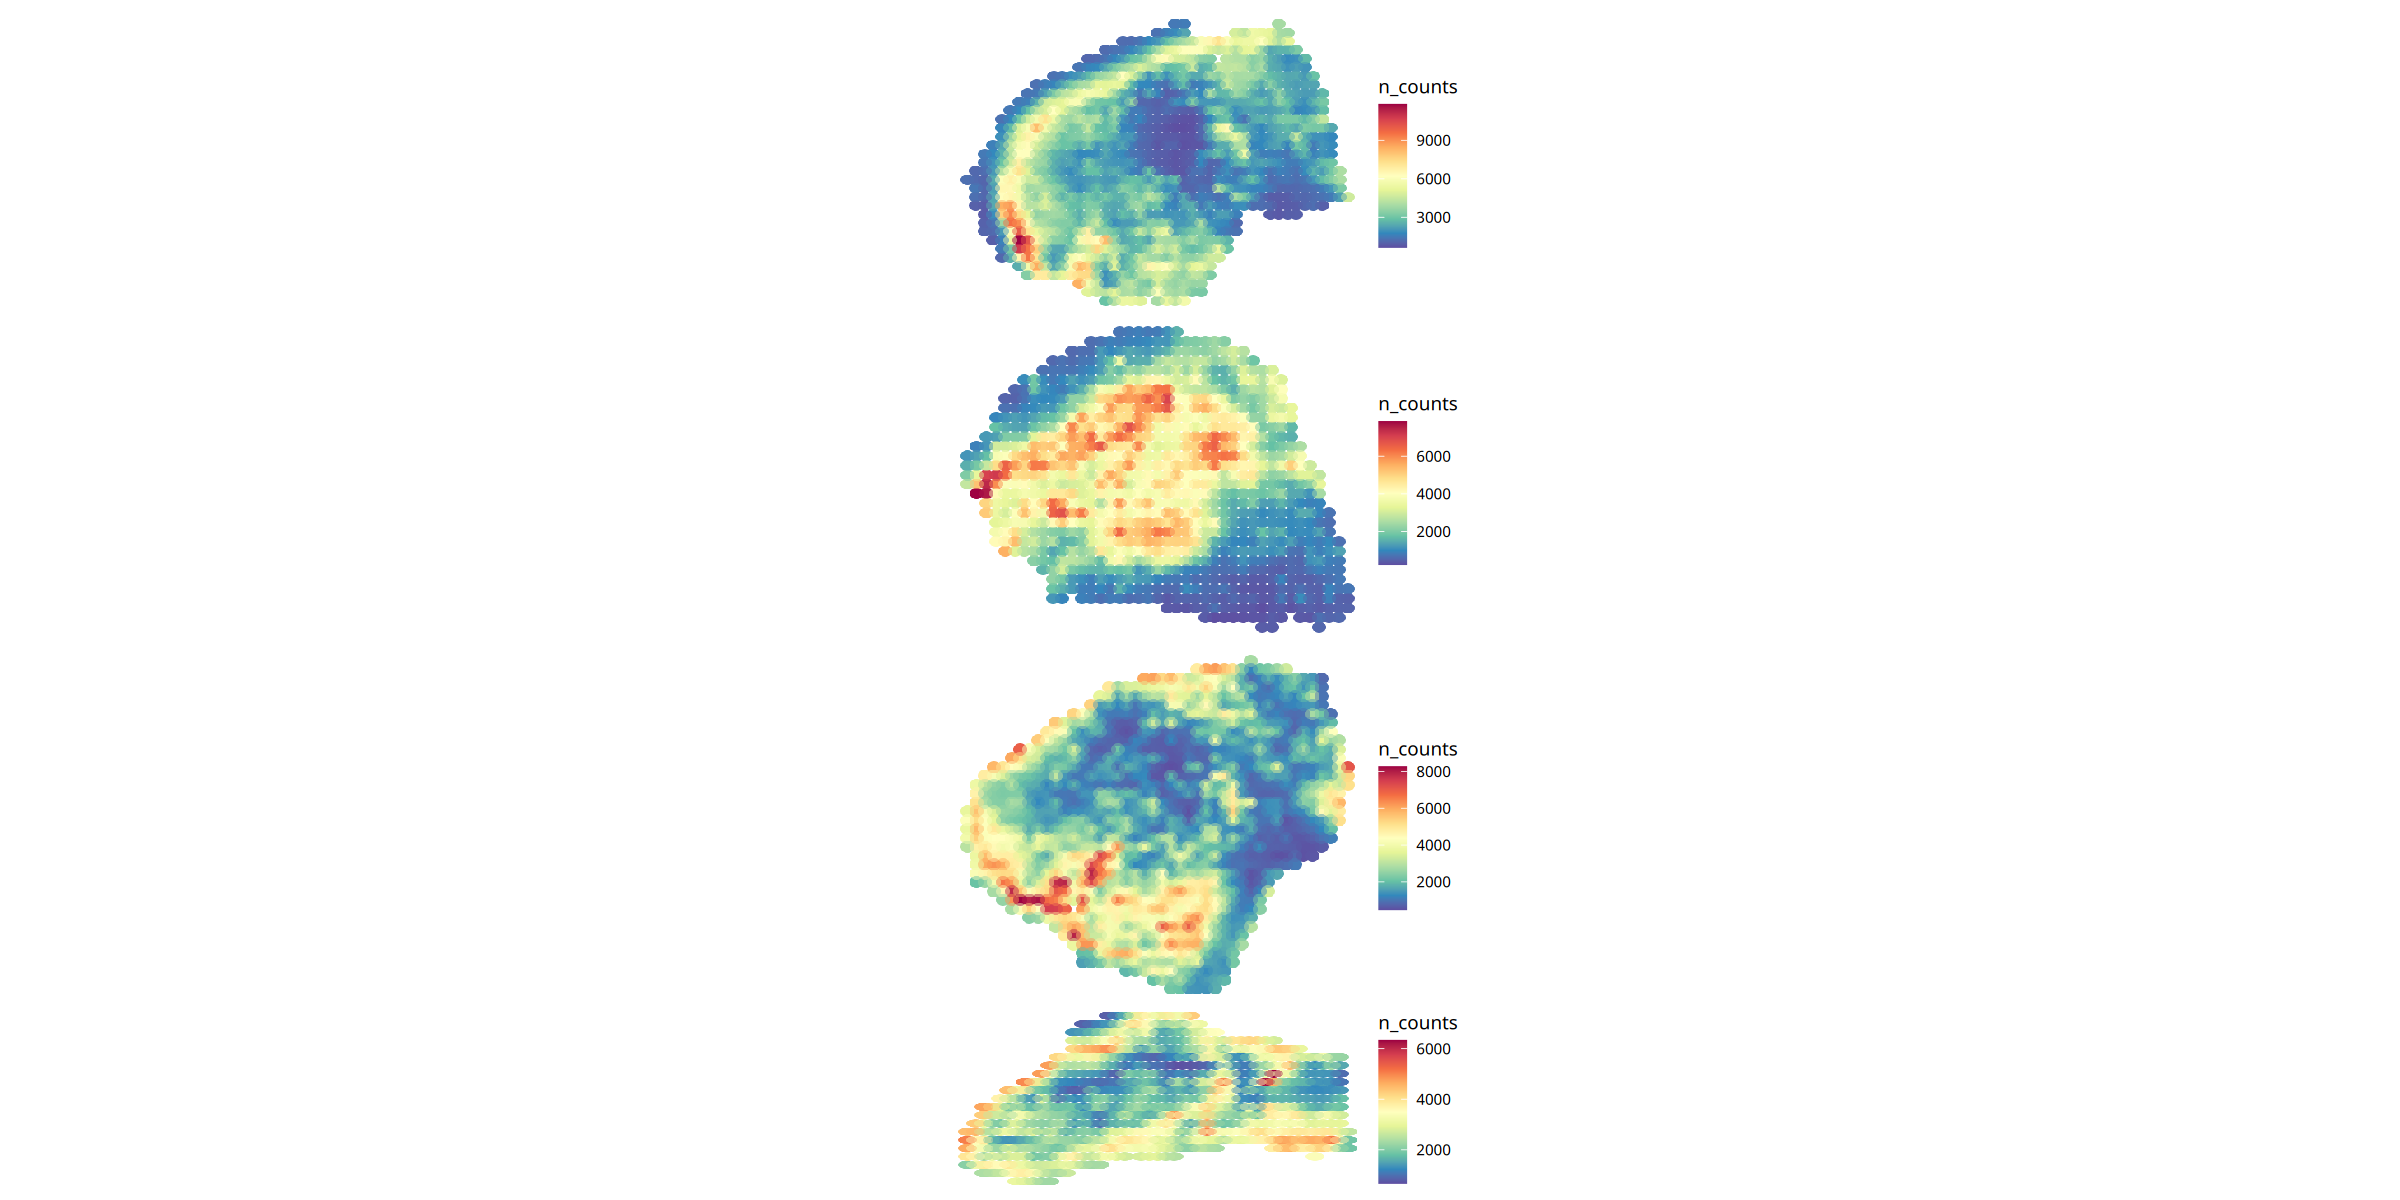

In [350]:
options(repr.plot.height=10,repr.plot.width=20)
plot_spatial_col(obj = obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D2.left',],col_name  = 'n_counts',size = 9)+
plot_spatial_col(obj = obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D2.right',],col_name  = 'n_counts',size = 9)+
plot_spatial_col(obj = obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D4.left',],col_name  = 'n_counts',size = 9)+
plot_spatial_col(obj = obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D4.right',],col_name  = 'n_counts',size = 12)+
plot_layout(nrow=4)

In [236]:
#obj_fish_ST_cluster <- obj_fish_ST_raw[,obj_fish_ST_raw$slice_code%in%c('D03558D2.left','D03558D4.left')]
#obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D4.left','x'] <- -obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D4.left','x']

In [9]:
obj_fish_ST_cluster <- obj_fish_ST_cluster[,obj_fish_ST_cluster$slice_code%in%c('D03558D2.left','D03558D4.left')]
obj_fish_ST_cluster@active.assay <- 'RNA'
obj_fish_ST_cluster <- NormalizeData(obj_fish_ST_cluster)
obj_fish_ST_cluster <- FindVariableFeatures(obj_fish_ST_cluster,nfeatures = 3000)
obj_fish_ST_cluster <- ScaleData(obj_fish_ST_cluster,verbose=FALSE,vars.to.regress = 'n_counts')
obj_fish_ST_cluster <- RunPCA(obj_fish_ST_cluster,npcs=30,verbose=FALSE)
obj_fish_ST_cluster <- RunHarmony(obj_fish_ST_cluster,verbose = F,reduction.use = 'pca',group.by.vars = 'slice_code')

In [10]:
obj_fish_ST_cluster <- RunUMAP(obj_fish_ST_cluster,dims=1:15,reduction = 'harmony',verbose = F)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


In [11]:
obj_fish_ST_cluster <- FindNeighbors(obj_fish_ST_cluster,reduction = 'harmony',dims=1:15)
obj_fish_ST_cluster <- FindClusters(obj_fish_ST_cluster,resolution = 0.5)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 2117
Number of edges: 85185

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.6982
Number of communities: 5
Elapsed time: 0 seconds


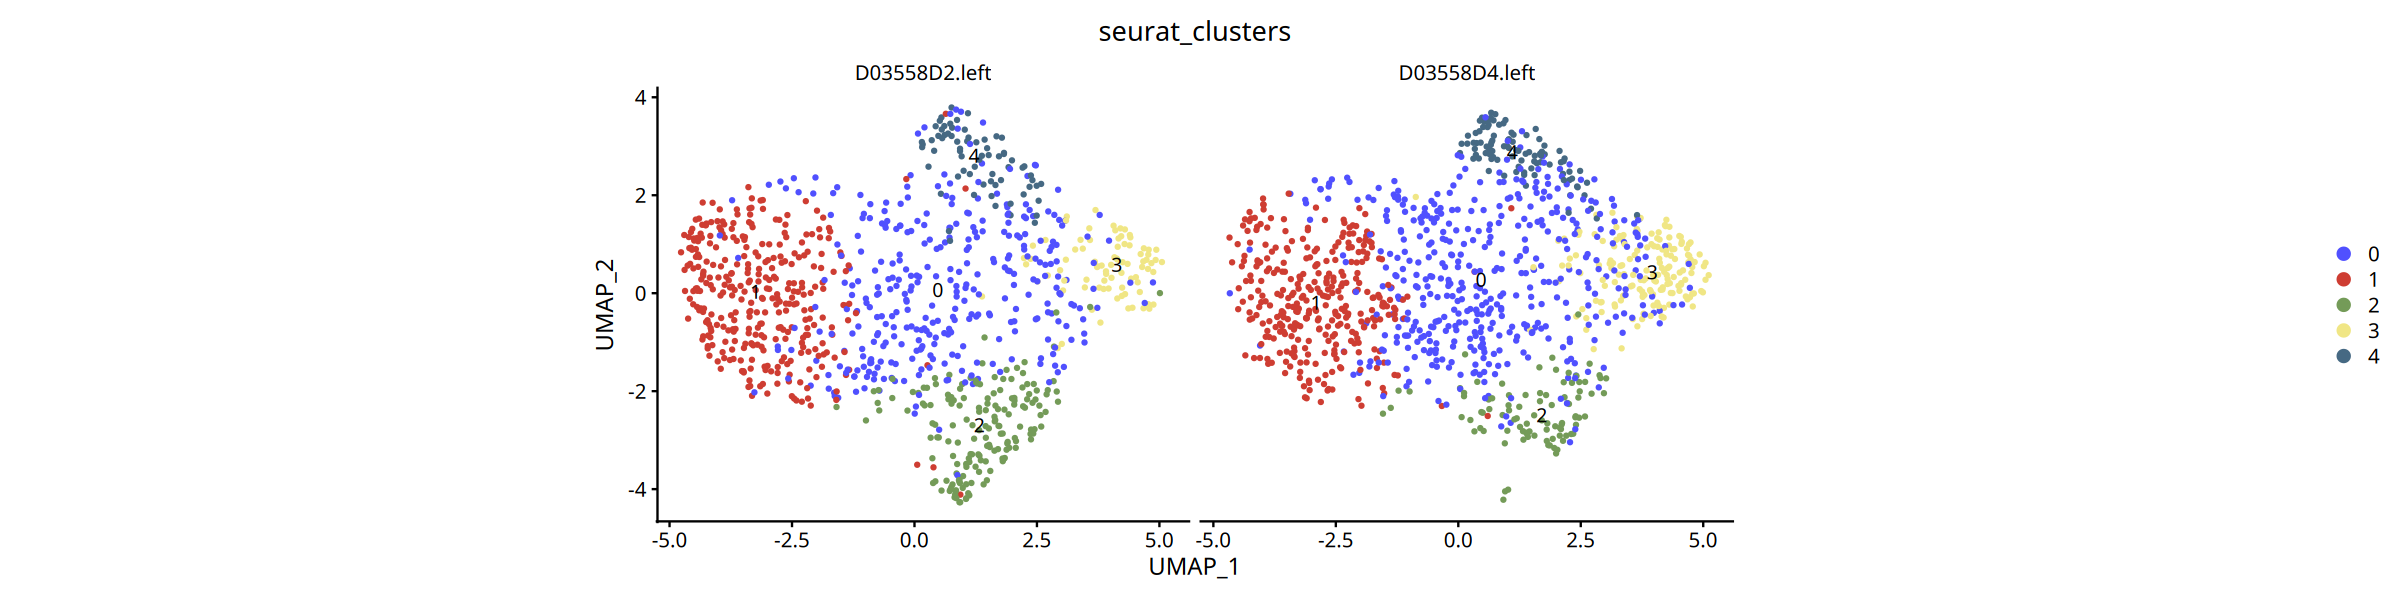

In [20]:
options(repr.plot.height=5,repr.plot.width=20)
DimPlot(obj_fish_ST_cluster,reduction = 'umap',split.by = 'slice_code',group.by='seurat_clusters',label=T)+
scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_fish_ST_cluster$seurat_clusters)))+
coord_fixed()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


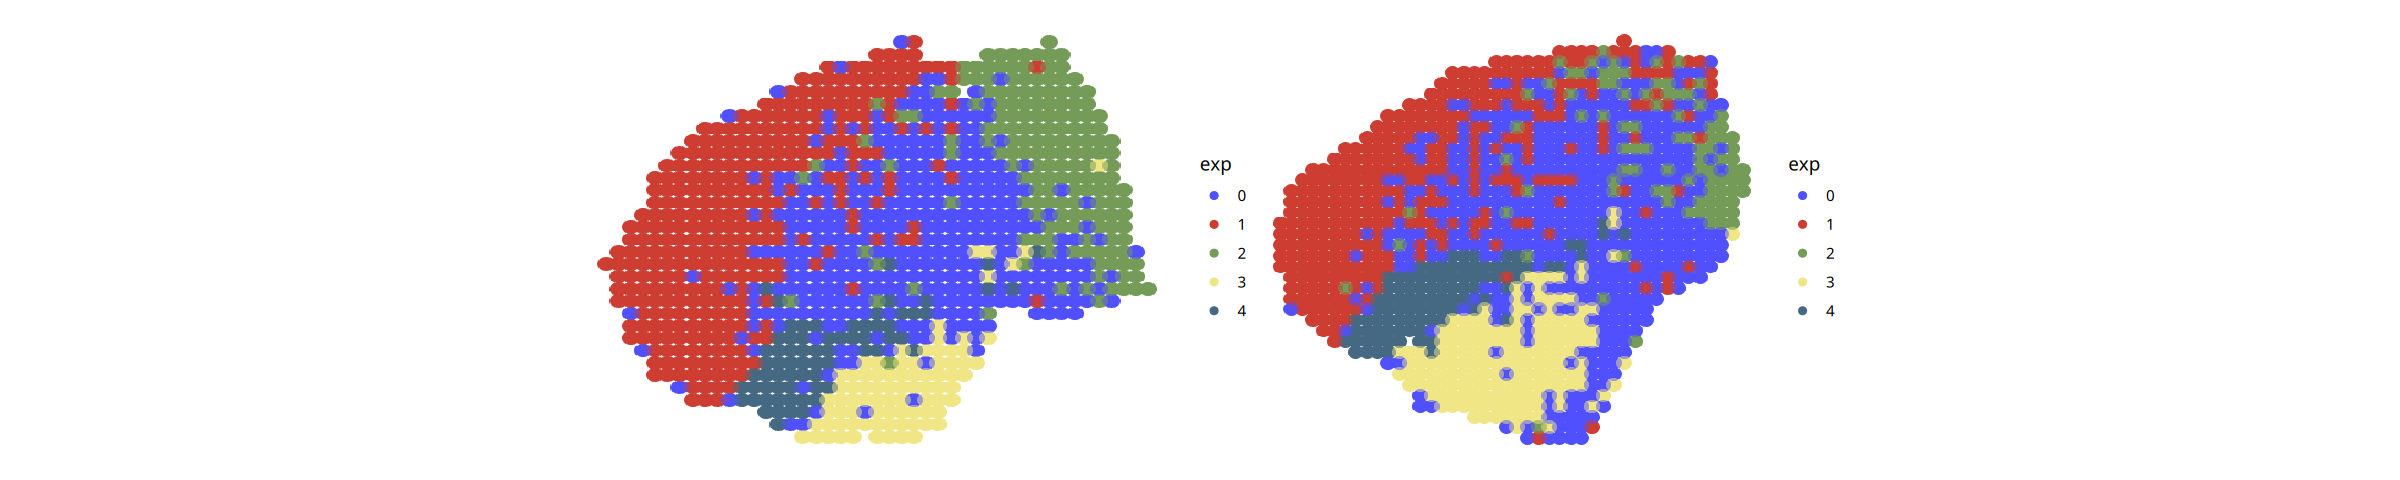

In [10]:
options(repr.plot.height=4,repr.plot.width=20)
p1 <- plot_spatial_col(obj = obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D2.left',],col_name  = 'seurat_clusters',size = 8)+
scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_fish_ST_cluster$seurat_clusters)))
#plot_spatial_col(obj = obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D2.right',],col_name  = 'seurat_clusters',size = 8)+scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_fish_ST_cluster$seurat_clusters)))+
p2 <- plot_spatial_col(obj = obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D4.left',],col_name  = 'seurat_clusters',size = 8)+
scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_fish_ST_cluster$seurat_clusters)))
#plot_spatial_col(obj = obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D4.right',],col_name  = 'seurat_clusters',size = 8)+scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_fish_ST_cluster$seurat_clusters)))+
p1+p2+plot_layout(ncol = 2)

In [8]:
source('../R_function/ST_plot.R')

In [25]:
getwd()

[1] "/mnt/gandan/huangzhi/jupyter/Multispecies"

In [37]:
save_real_plot(p1,dir_path = 'Plot/Region_mask/',name = 'fish_D2',
               plot_x_vector = obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D2.left',]$x,
               plot_y_vector = obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D2.left',]$y,edge_add = 50)
save_real_plot(p2,dir_path = 'Plot/Region_mask/',name = 'fish_D4',
               plot_x_vector = obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D4.left',]$x,
               plot_y_vector = obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D4.left',]$y,edge_add = 50)

Coordinate system already present. Adding new coordinate system, which will
replace the existing one.
Coordinate system already present. Adding new coordinate system, which will
replace the existing one.


In [44]:
fish_mask1 <- read_real_mask_plot('Plot/Region_mask/fish_D2_mask_775_-1115.tif',x_offset = 775, y_offset = -1115)
fish_mask2 <- read_real_mask_plot('Plot/Region_mask/fish_D4_mask_815_-1005.tif',x_offset = 815, y_offset = -1005)
fish_mask1$region <- c('200'='aDP','255'='pDP','100'='cDP','175'='aVP','150'='pVP')[as.character(fish_mask1$mask)]
fish_mask2$region <- c('200'='aDP','255'='pDP','100'='cDP','175'='aVP','150'='pVP')[as.character(fish_mask2$mask)]
obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster$slice_code=='D03558D2.left',] <- df_add_mask(
    obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster$slice_code=='D03558D2.left',],
            fish_mask1,imputation = F,mask_col = 'region')
obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster$slice_code=='D03558D4.left',] <- df_add_mask(
    obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster$slice_code=='D03558D4.left',],
            fish_mask2,imputation = F,mask_col = 'region')

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


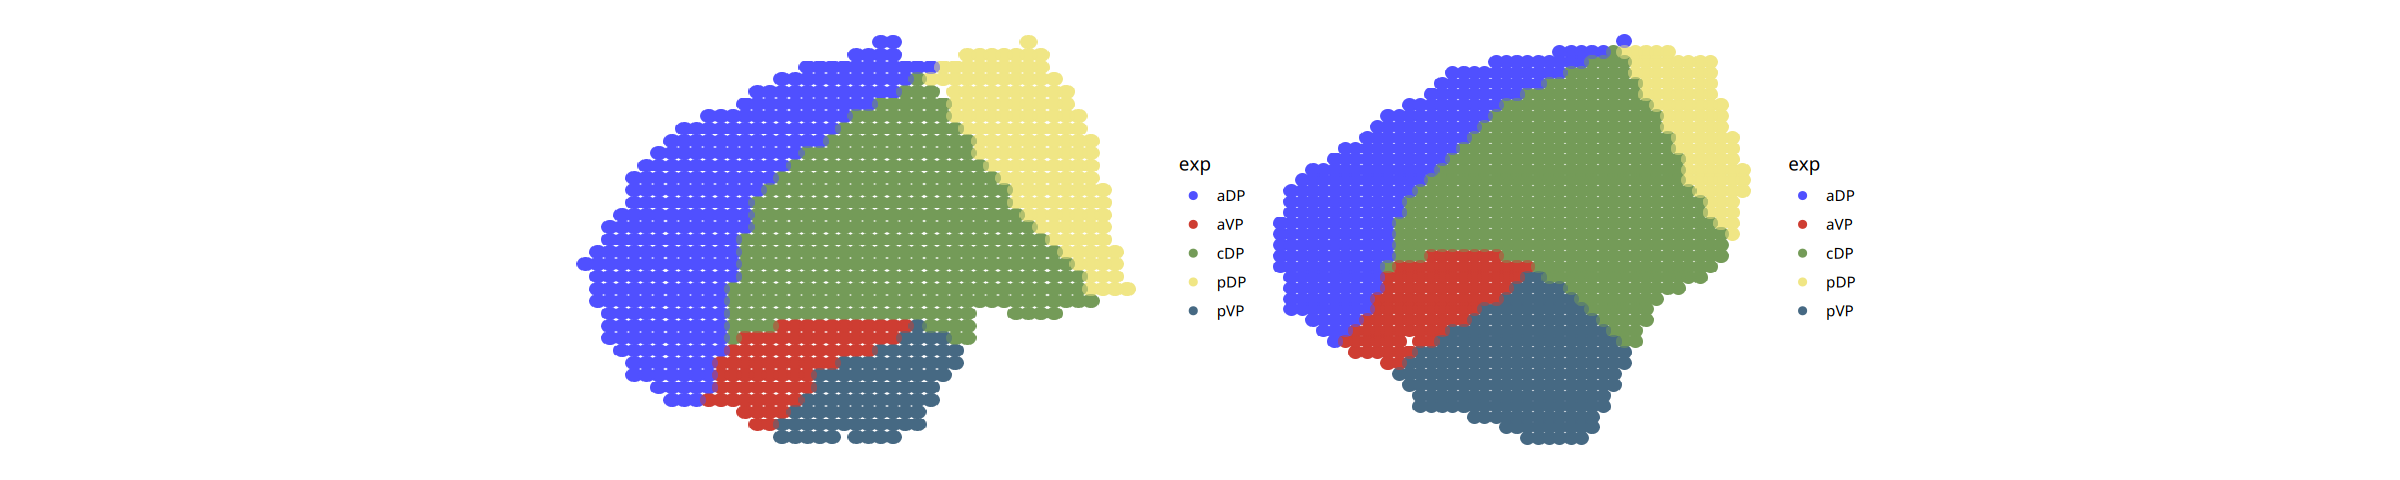

In [45]:
options(repr.plot.height=4,repr.plot.width=20)
p1 <- plot_spatial_col(obj = obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D2.left',],col_name  = 'region',size = 8)+
scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_fish_ST_cluster$region)))
#plot_spatial_col(obj = obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D2.right',],col_name  = 'seurat_clusters',size = 8)+scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_fish_ST_cluster$seurat_clusters)))+
p2 <- plot_spatial_col(obj = obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D4.left',],col_name  = 'region',size = 8)+
scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_fish_ST_cluster$region)))
#plot_spatial_col(obj = obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D4.right',],col_name  = 'seurat_clusters',size = 8)+scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_fish_ST_cluster$seurat_clusters)))+
p1+p2+plot_layout(ncol = 2)

In [49]:
saveRDS(obj_fish_ST_cluster,'Analysis/Region_defined/Gene_fish_DPVP.rds')

In [1]:
obj_fish_ST_cluster <- readRDS('Analysis/Region_defined/Gene_fish_DPVP.rds')

In [4]:
obj_fish_ST_cluster_DP <- obj_fish_ST_cluster[,obj_fish_ST_cluster$region%in%c('aDP','pDP','cDP')]
obj_fish_ST_cluster_DP@active.assay <- 'RNA'
obj_fish_ST_cluster_DP <- NormalizeData(obj_fish_ST_cluster_DP)
obj_fish_ST_cluster_DP <- FindVariableFeatures(obj_fish_ST_cluster_DP,nfeatures = 3000)
obj_fish_ST_cluster_DP <- ScaleData(obj_fish_ST_cluster_DP,verbose=FALSE,vars.to.regress = 'n_counts')
obj_fish_ST_cluster_DP <- RunPCA(obj_fish_ST_cluster_DP,npcs=30,verbose=FALSE)
obj_fish_ST_cluster_DP <- RunHarmony(obj_fish_ST_cluster_DP,verbose = F,reduction.use = 'pca',group.by.vars = 'slice_code')

In [5]:
obj_fish_ST_cluster_DP <- RunUMAP(obj_fish_ST_cluster_DP,dims=1:15,reduction = 'harmony',verbose = F)
obj_fish_ST_cluster_DP <- FindNeighbors(obj_fish_ST_cluster_DP,reduction = 'harmony',dims=1:15)
obj_fish_ST_cluster_DP <- FindClusters(obj_fish_ST_cluster_DP,resolution = 0.35)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 1640
Number of edges: 67312

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7755
Number of communities: 3
Elapsed time: 0 seconds


In [61]:
obj_fish_ST_cluster_DP <- FindClusters(obj_fish_ST_cluster_DP,resolution = 0.35)

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 1640
Number of edges: 68487

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7127
Number of communities: 3
Elapsed time: 0 seconds


pdf 
  2

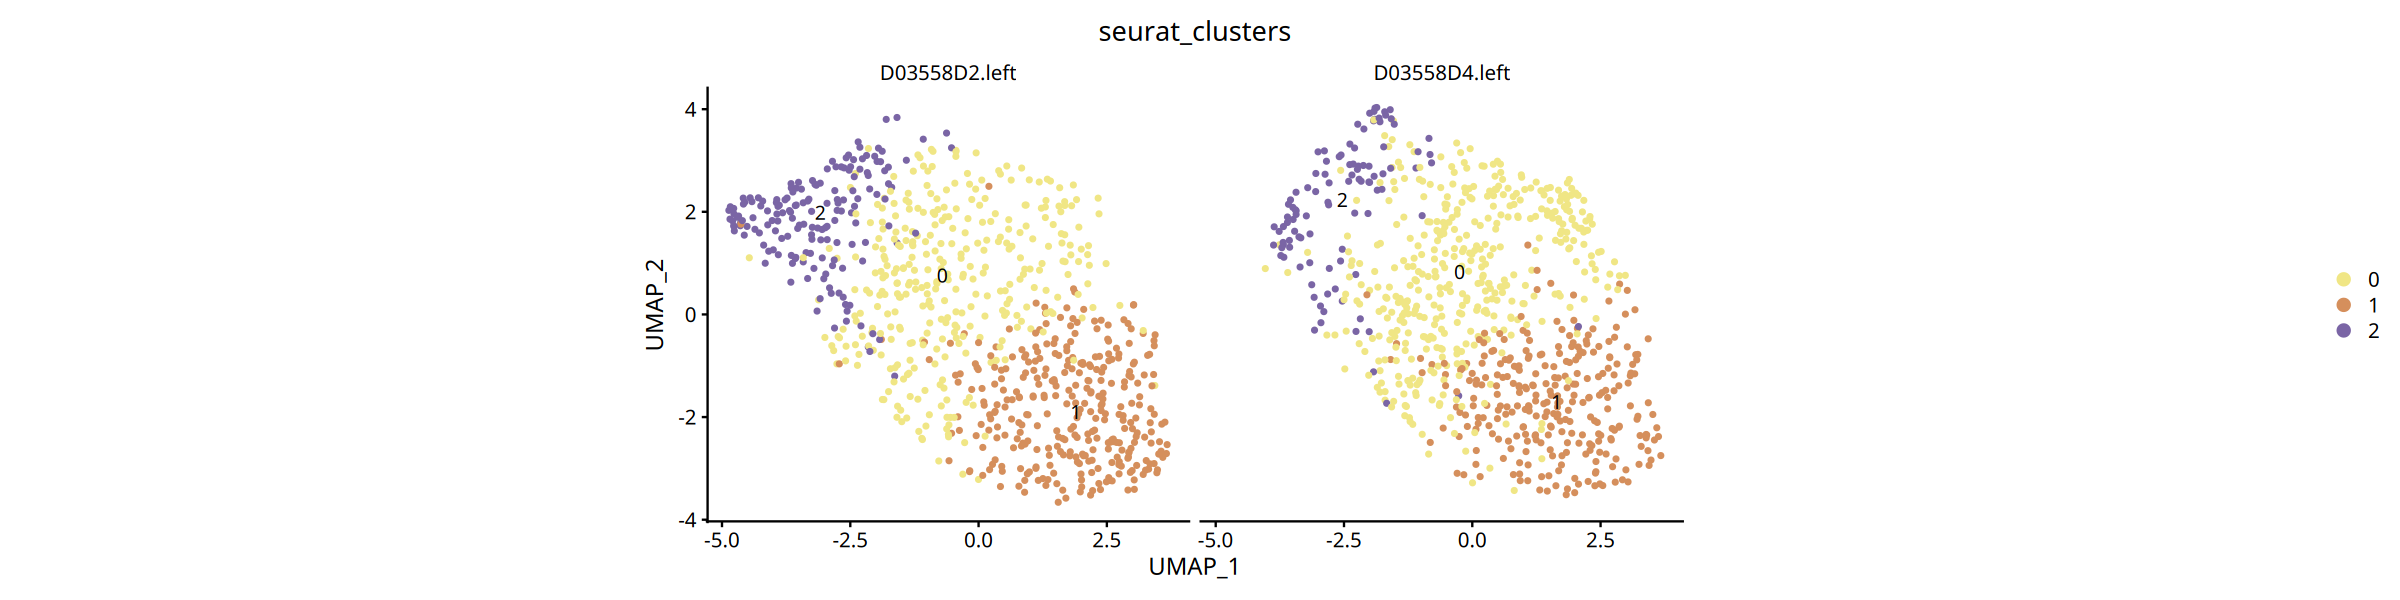

In [88]:
options(repr.plot.height=5,repr.plot.width=20)
p <- DimPlot(obj_fish_ST_cluster_DP,reduction = 'umap',split.by = 'slice_code',group.by='seurat_clusters',label=T)+
scale_color_manual(values = pal_igv()(50)[c(4,14,15)],breaks = sort(unique(obj_fish_ST_cluster_DP$seurat_clusters)))+
coord_fixed()
p
pdf('Plot/Region_cluster/Fish_umap_cluster.pdf',height = 5,width = 20)
p
dev.off()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

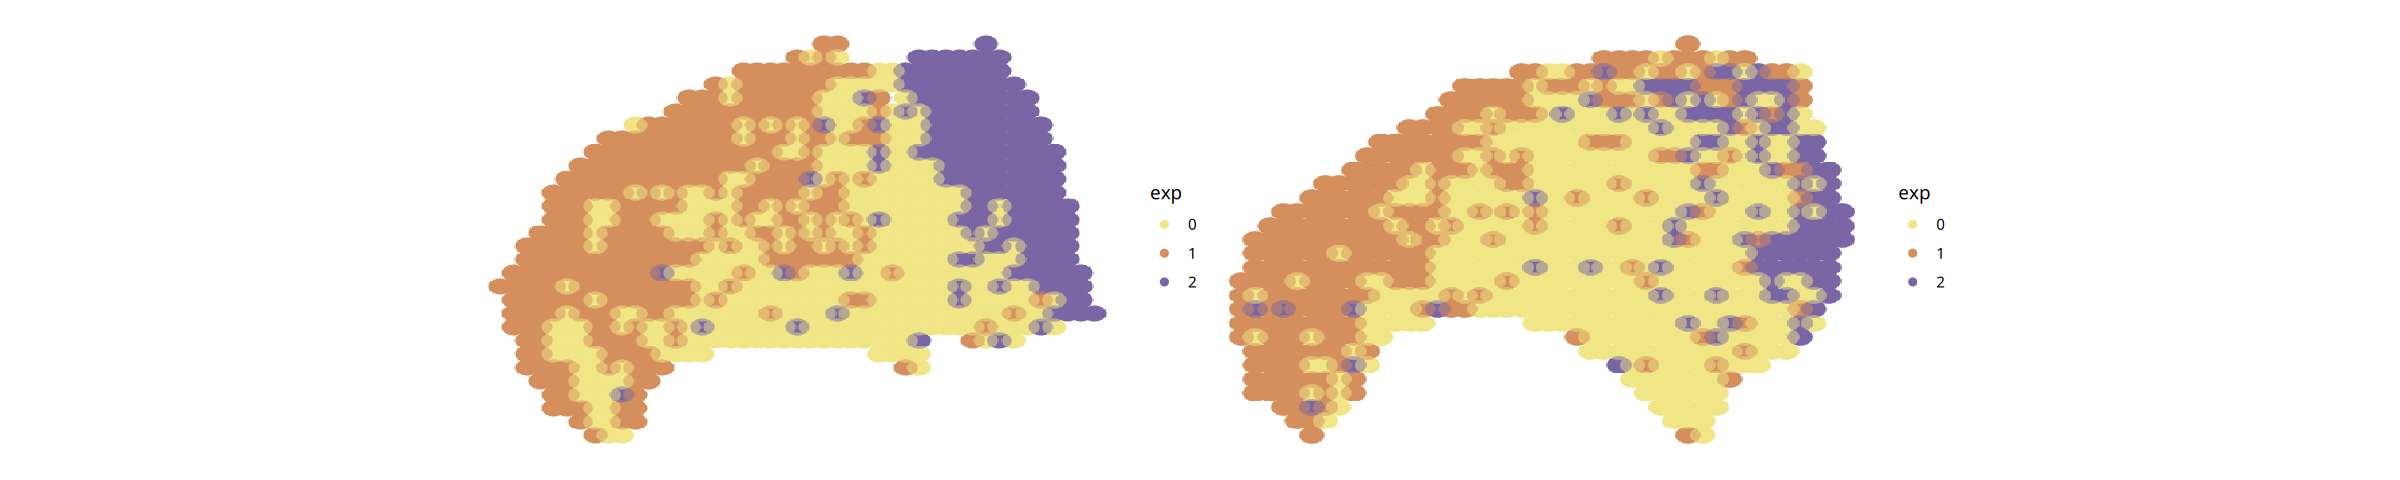

In [90]:
options(repr.plot.height=4,repr.plot.width=20)
p1 <- plot_spatial_col(obj = obj_fish_ST_cluster_DP@meta.data[obj_fish_ST_cluster_DP@meta.data$slice_code=='D03558D2.left',],col_name  = 'seurat_clusters',size = 9.5)+
scale_color_manual(values = pal_igv()(50)[c(4,14,15)],breaks = sort(unique(obj_fish_ST_cluster_DP$seurat_clusters)))
#plot_spatial_col(obj = obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D2.right',],col_name  = 'seurat_clusters',size = 8)+scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_fish_ST_cluster$seurat_clusters)))+
p2 <- plot_spatial_col(obj = obj_fish_ST_cluster_DP@meta.data[obj_fish_ST_cluster_DP@meta.data$slice_code=='D03558D4.left',],col_name  = 'seurat_clusters',size = 9.8)+
scale_color_manual(values = pal_igv()(50)[c(4,14,15)],breaks = sort(unique(obj_fish_ST_cluster_DP$seurat_clusters)))
#plot_spatial_col(obj = obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D4.right',],col_name  = 'seurat_clusters',size = 8)+scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_fish_ST_cluster$seurat_clusters)))+
p1+p2+plot_layout(ncol = 2)

pdf('Plot/Region_cluster/Fish_spatial_cluster.pdf',height = 4,width = 20)
p1+p2+plot_layout(ncol = 2)
dev.off()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

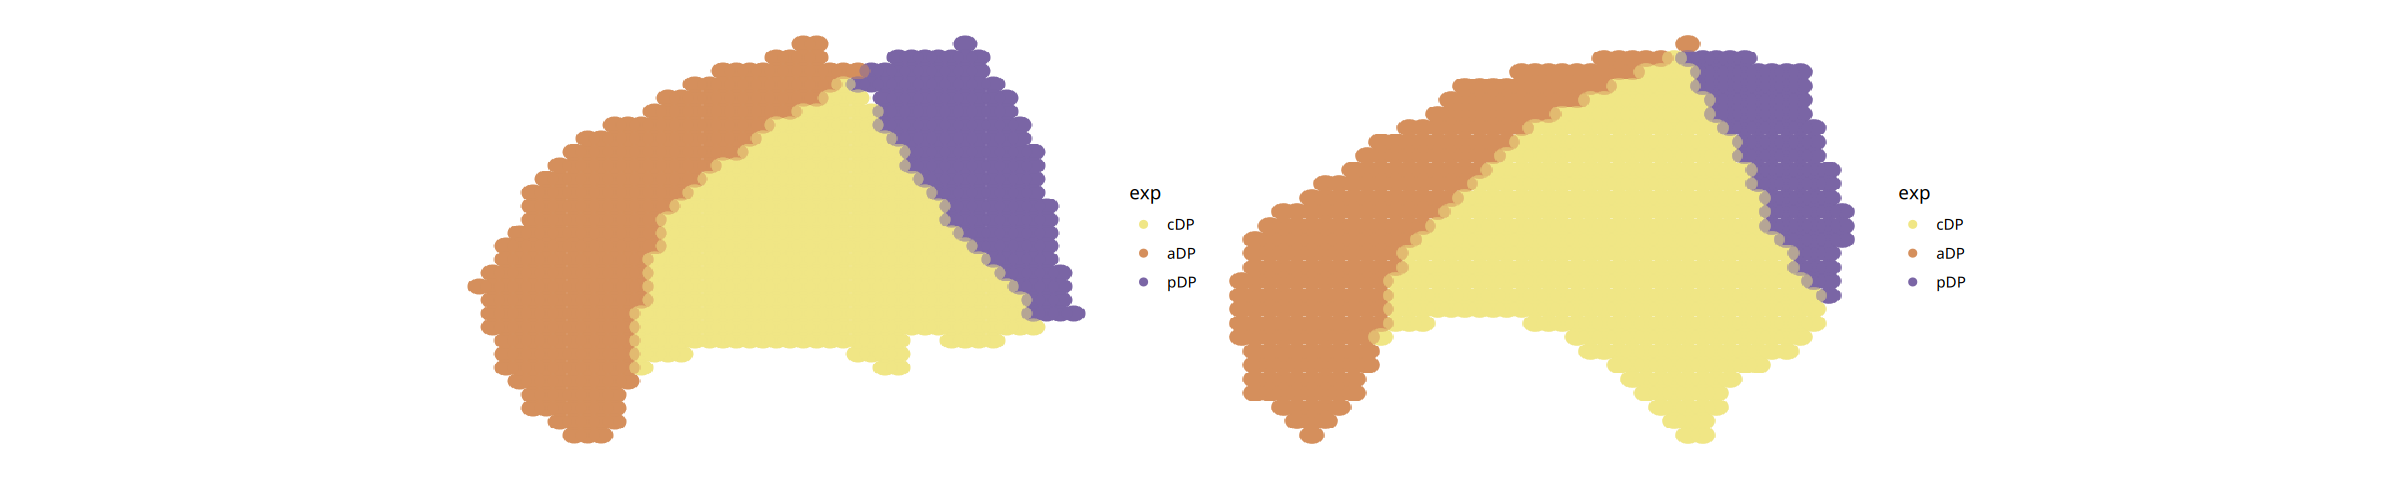

In [91]:
options(repr.plot.height=4,repr.plot.width=20)
p1 <- plot_spatial_col(obj = obj_fish_ST_cluster_DP@meta.data[obj_fish_ST_cluster_DP@meta.data$slice_code=='D03558D2.left',],col_name  = 'region',size = 9.5)+
scale_color_manual(values = pal_igv()(50)[c(4,14,15)],breaks = c('cDP','aDP','pDP'))
#plot_spatial_col(obj = obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D2.right',],col_name  = 'seurat_clusters',size = 8)+scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_fish_ST_cluster$seurat_clusters)))+
p2 <- plot_spatial_col(obj = obj_fish_ST_cluster_DP@meta.data[obj_fish_ST_cluster_DP@meta.data$slice_code=='D03558D4.left',],col_name  = 'region',size = 9.8)+
scale_color_manual(values = pal_igv()(50)[c(4,14,15)],breaks = c('cDP','aDP','pDP'))
#plot_spatial_col(obj = obj_fish_ST_cluster@meta.data[obj_fish_ST_cluster@meta.data$slice_code=='D03558D4.right',],col_name  = 'seurat_clusters',size = 8)+scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_fish_ST_cluster$seurat_clusters)))+
p1+p2+plot_layout(ncol = 2)

pdf('Plot/Region_cluster/Fish_spatial_manual.pdf',height = 5,width = 20)
p1+p2+plot_layout(ncol = 2)
dev.off()

In [65]:
saveRDS(obj_fish_ST_cluster_DP,'Analysis/Region_defined/Gene_fish.rds')